Customer Intelligence System using Classification, Ensemble Learning & Clustering
Project Objective

This project develops a Customer Intelligence System using unsupervised and supervised machine learning techniques. The objective is to segment countries based on socio-economic indicators and build predictive models capable of classifying countries into their corresponding segments.

Techniques used:

Data Cleaning
Exploratory Data Analysis (EDA)
Feature Scaling
K-Means Clustering
DBSCAN Clustering
PCA Visualization
Random Forest Classification
XGBoost Classification

In [31]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost -q

In [32]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [33]:
df = pd.read_csv('country-data.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [34]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 167
Columns : 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


Data Cleaning
Removing whitespace, duplicates, converting datatypes and handling missing values

In [35]:
# Remove whitespace from column names

df.columns = df.columns.str.strip()

# Remove duplicate rows

df = df.drop_duplicates()

# Convert columns to numeric

for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values using median

for col in df.columns[1:]:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing Values")
print(df.isnull().sum())

print("\nDuplicates")
print(df.duplicated().sum())

Missing Values
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicates
0


In [36]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


Correlation Heatmap

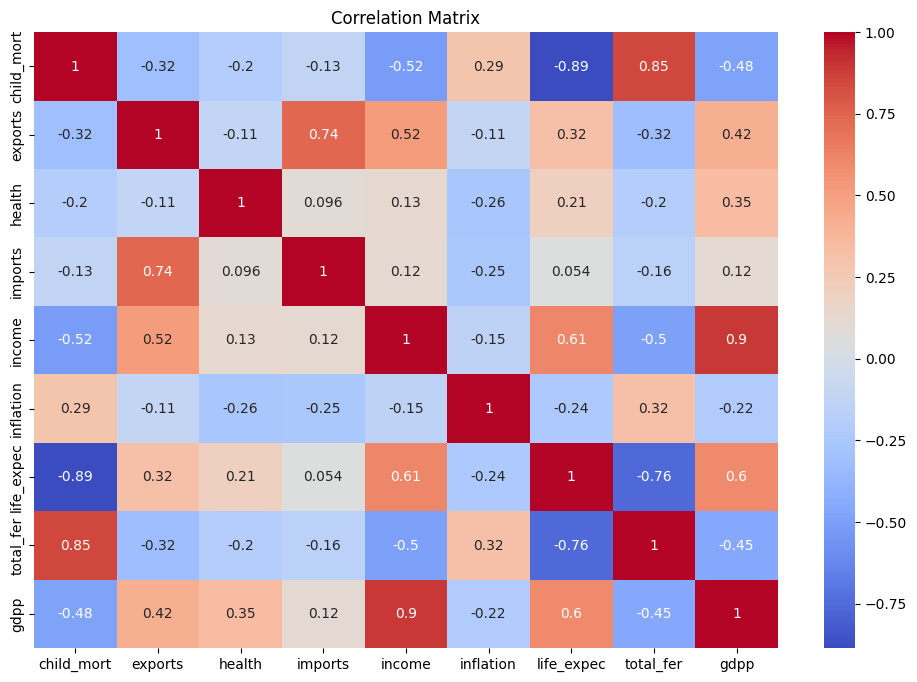

In [37]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop('country',axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

Histograms

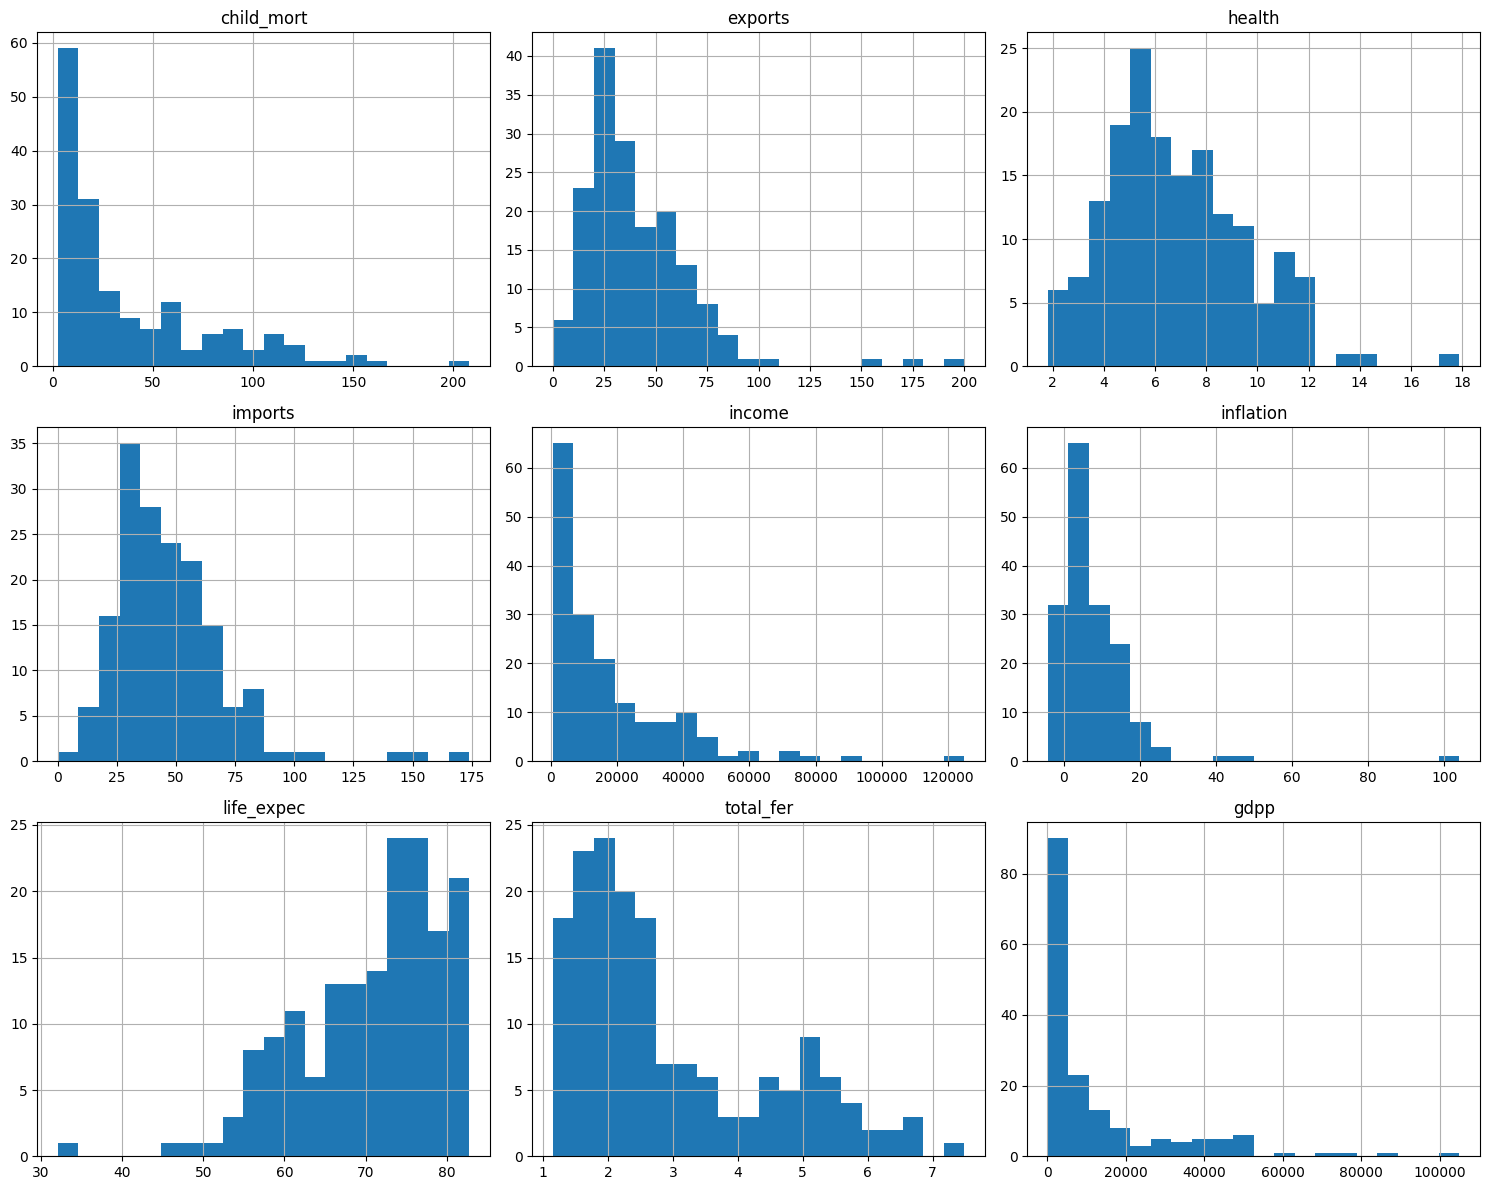

In [38]:
df.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()

Boxplots

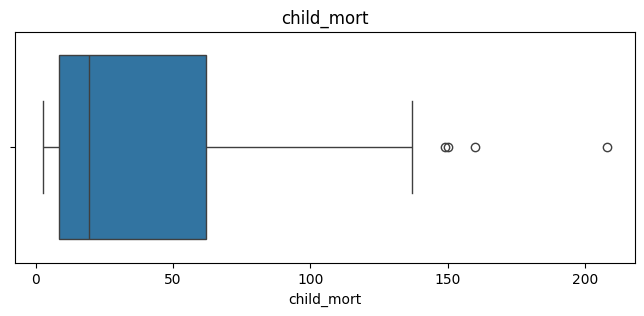

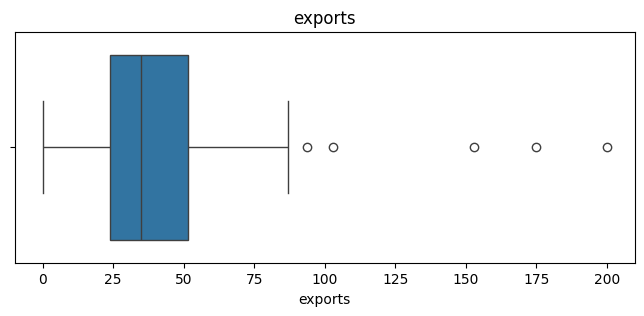

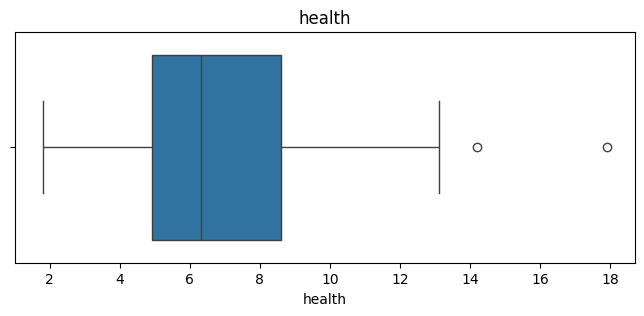

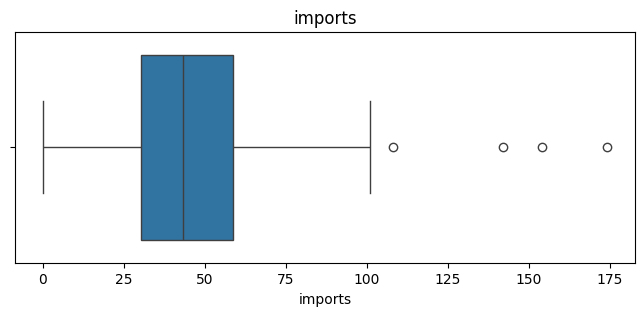

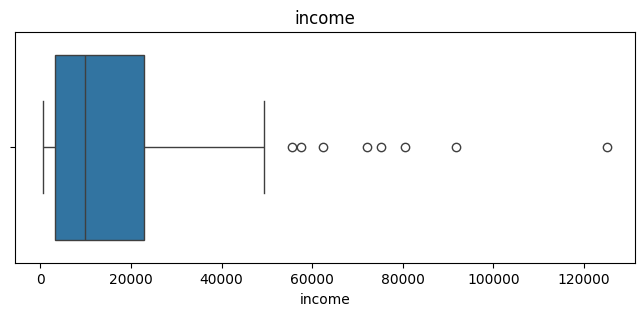

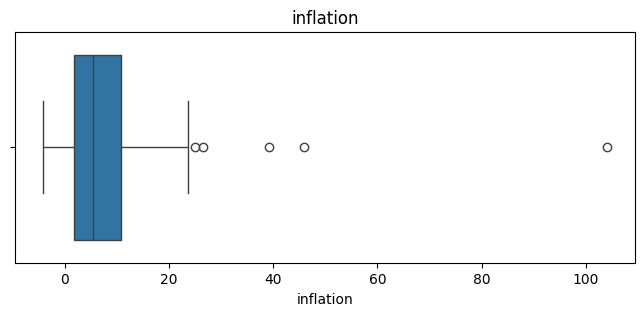

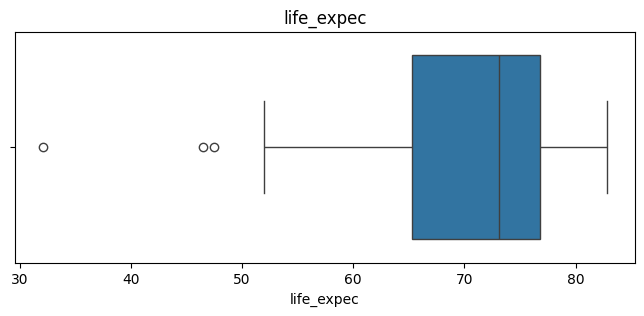

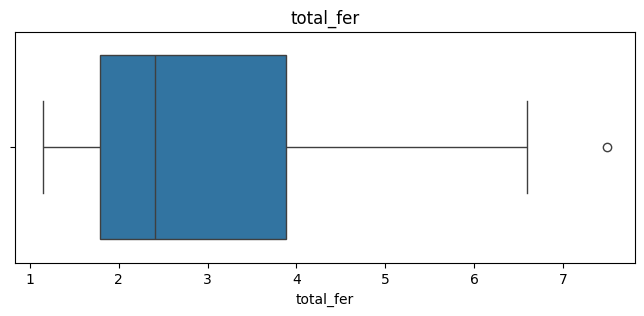

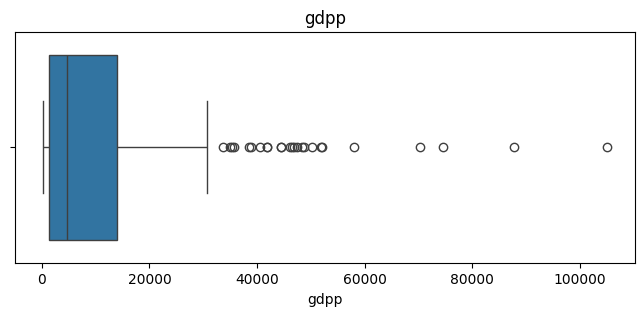

In [39]:
for col in df.columns[1:]:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

Feature Selection

In [40]:
X = df.drop('country', axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Feature Scaling

In [41]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


Elbow Method

In [42]:
wcss = []

for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

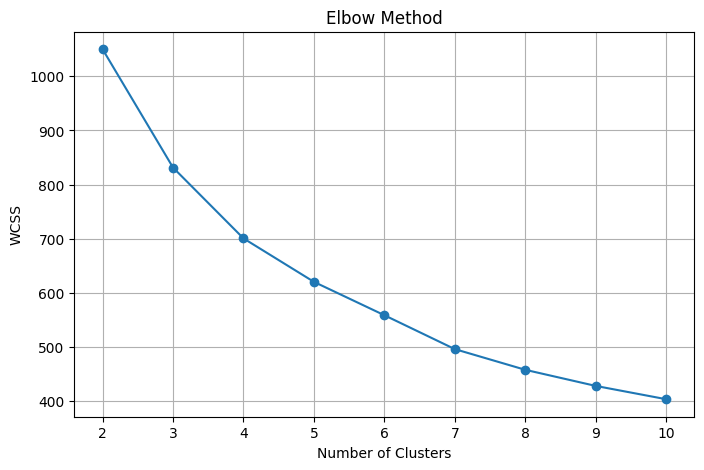

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

K-Means Clustering

In [44]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df[['country','Cluster']].head()

,country,Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


Silhouette Score

In [45]:
sil_score = silhouette_score(
    X_scaled,
    df['Cluster']
)

print("Silhouette Score :", round(sil_score,4))

Silhouette Score : 0.2833


In [46]:
df['Cluster'].value_counts()

Cluster
2    84
1    47
0    36
Name: count, dtype: int64

DBSCAN Clustering

In [47]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64

PCA Dimensionality Reduction

In [48]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df.head()

,PC1,PC2
0,-2.913025,0.095621
1,0.429911,-0.588156
2,-0.285225,-0.455174
3,-2.932423,1.695555
4,1.033576,0.136659


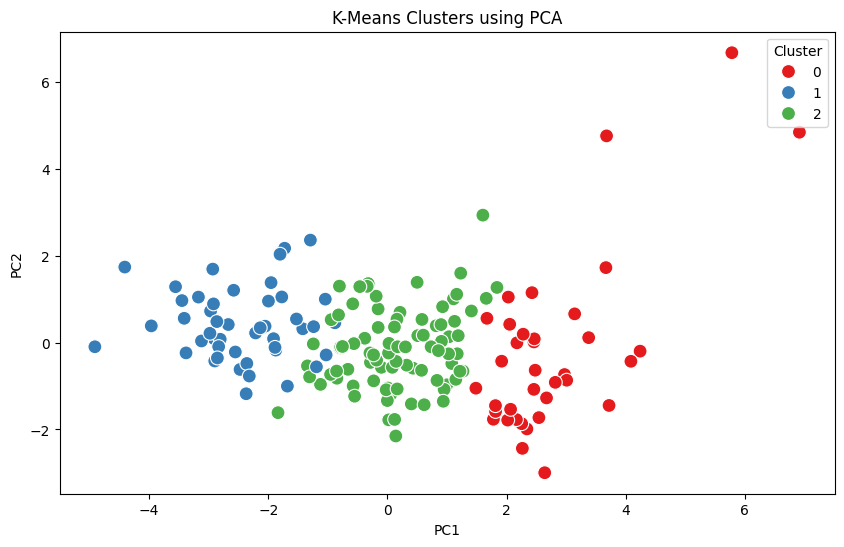

In [49]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

plt.title("K-Means Clusters using PCA")

plt.show()

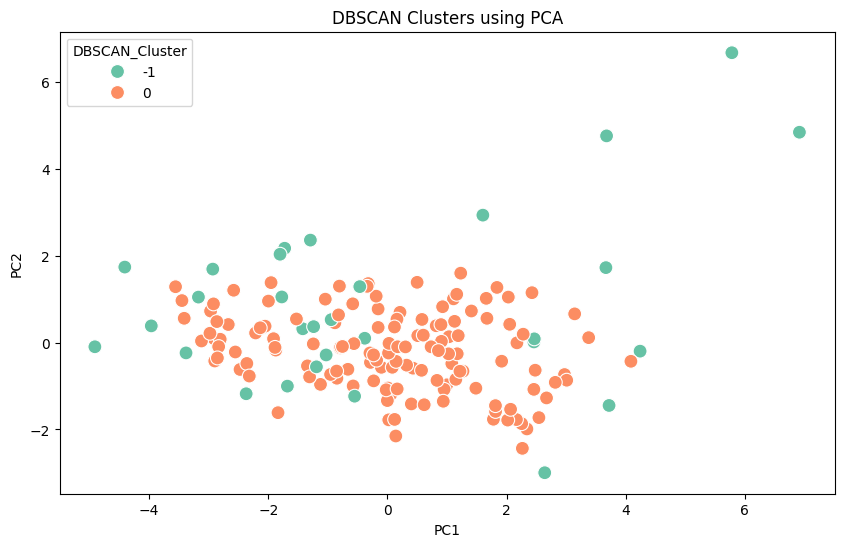

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=df['DBSCAN_Cluster'],
    palette='Set2',
    s=100
)

plt.title("DBSCAN Clusters using PCA")

plt.show()

In [51]:
cluster_profile = df.groupby(
    'Cluster'
).mean(numeric_only=True)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


Creating Target Variable

In [52]:
df['Segment'] = df['Cluster']

X_cls = df.drop(
    ['country',
     'Cluster',
     'DBSCAN_Cluster',
     'Segment'],
    axis=1
)

y_cls = df['Segment']

Train Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)

Random Forest

In [54]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,rf_pred))

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



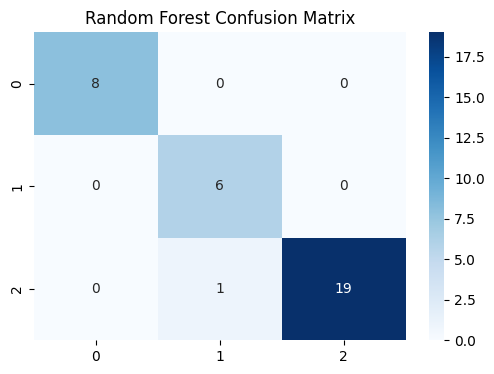

In [55]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.show()

Feature Importance

In [56]:
importance = pd.DataFrame({

    'Feature': X_cls.columns,

    'Importance':
    rf.feature_importances_

}).sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.279315
8,gdpp,0.196765
4,income,0.155490
6,life_expec,0.151215
7,total_fer,0.149904
2,health,0.032411
5,inflation,0.014174
1,exports,0.013982
3,imports,0.006743


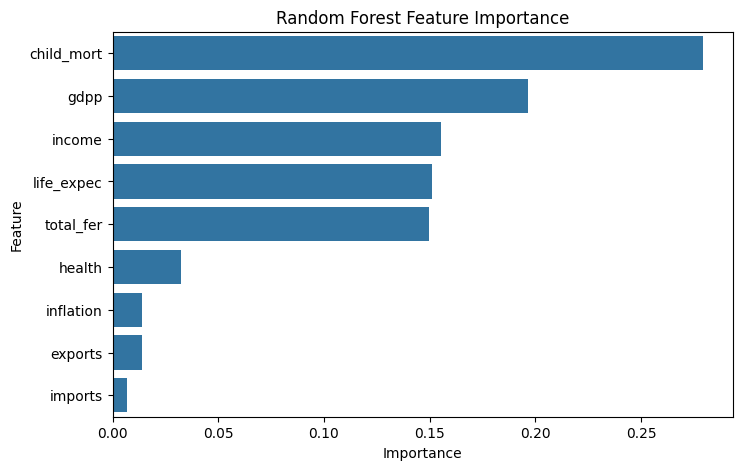

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

XGBoost

In [58]:
xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test,xgb_pred)
)

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



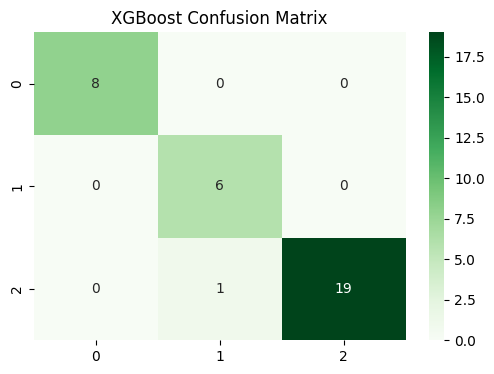

In [59]:
cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

Model Comparison

In [60]:
rf_acc = accuracy_score(
    y_test,
    rf_pred
)

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

comparison = pd.DataFrame({

    'Model':
    ['Random Forest','XGBoost'],

    'Accuracy':
    [rf_acc,xgb_acc]

})

comparison

,Model,Accuracy
0,Random Forest,0.970588
1,XGBoost,0.970588


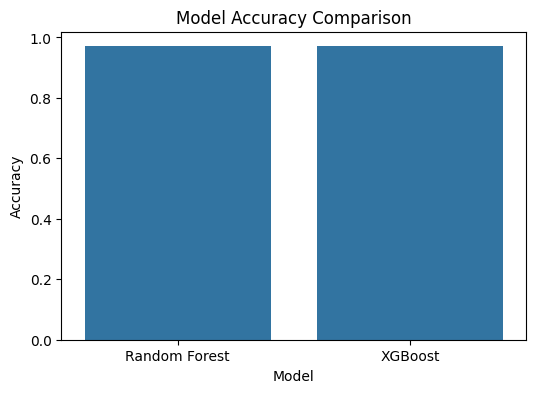

In [61]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")

plt.show()

Observation 1: High Mortality Countries

Cluster 0 contains countries with relatively high child mortality rates and lower life expectancy. These countries generally require improvements in healthcare infrastructure, sanitation, and nutrition programs.

Observation 2: Top Economic Zone

Cluster 1 represents economically developed nations characterized by high GDP per capita, strong income levels, low child mortality, and excellent healthcare standards. These countries form the most prosperous segment.

Observation 3: Low Development Region

Cluster 2 consists of countries with lower industrial development, lower income levels, and weaker socio-economic indicators. These countries may benefit from foreign investment, education reforms, and economic development initiatives.

Observation 4: Income and GDP Impact

Income and GDP per capita emerge as major differentiating variables across clusters, indicating strong influence on country segmentation.

Observation 5: Life Expectancy Relationship

Countries with higher life expectancy generally exhibit lower child mortality and stronger economic indicators, highlighting the relationship between economic development and public health outcomes.

Final Conclusion

The Customer Intelligence System successfully segmented countries into meaningful socio-economic groups using K-Means and DBSCAN clustering techniques. The Silhouette Score confirmed a stable cluster configuration, while PCA visualization demonstrated clear separation among segments. Random Forest and XGBoost classifiers accurately learned cluster patterns and achieved strong predictive performance. The analysis identified distinct high-development, developing, and low-development country groups, providing actionable insights for policy planning, economic assessment, and strategic decision-making.